# Generalised Amplitude Amplification

GAA Analysis: Target = $|11\rangle$

Iterations applied: 2
Initial bias angle (Ry): 1.047 radians


1. Circuit Visualisation

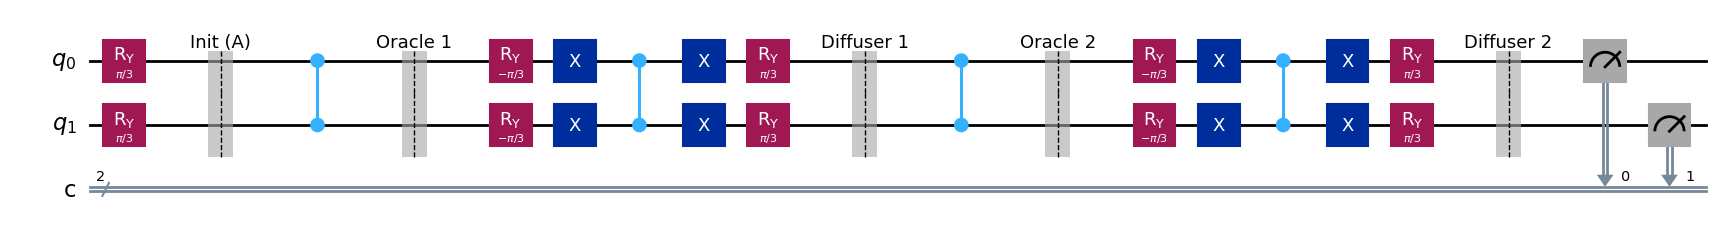

2. Unitary Evolution

The 4x4 unitary matrix describing the full circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


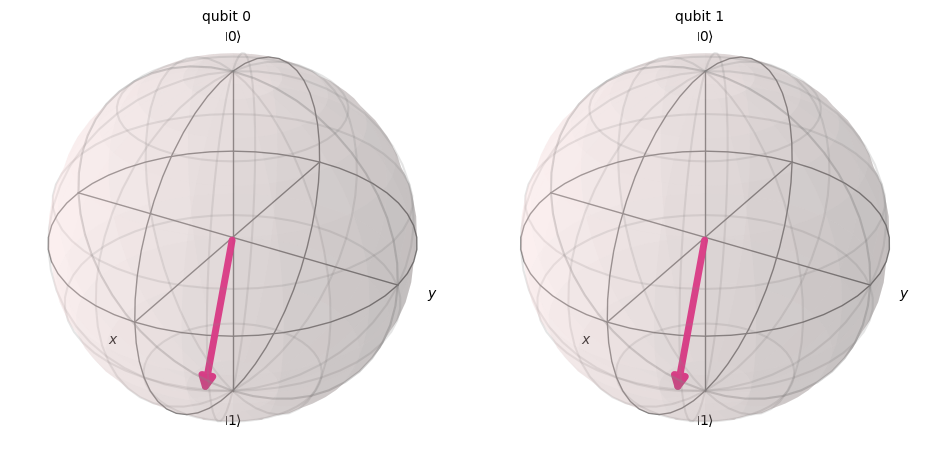


State prior to measurement (Q-Sphere):


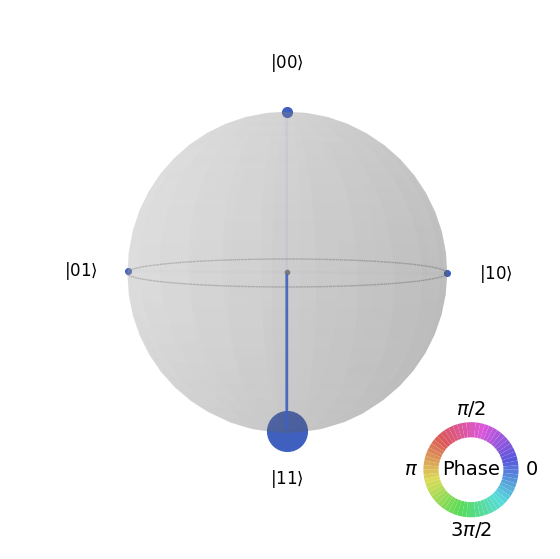

5. Measurement Analysis

Raw measurement counts: {'01': 24, '10': 17, '00': 62, '11': 921}


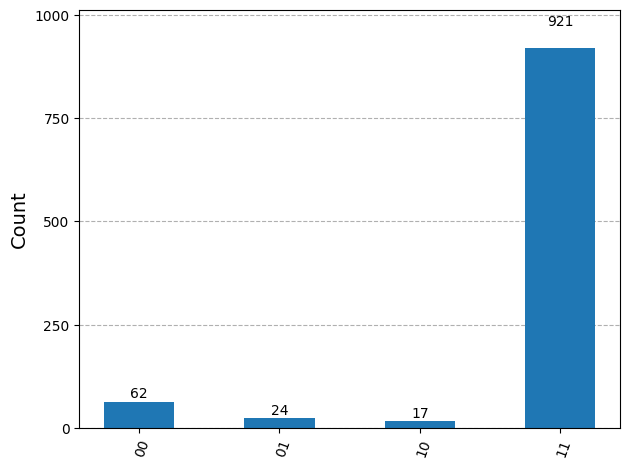

6. Verification

Success: The algorithm correctly amplified the target state '11'.
Final Success Probability: 89.94%


In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
target_string = "11"
n = len(target_string)
iterations = 2           # Number of amplifications
ry_angle = np.pi / 3     # The bias angle for our custom A operator

# Helper function for multi-controlled Z (scales to n qubits)
def apply_mcz(qc, qubits):
    if len(qubits) == 1:
        qc.z(qubits[0])
    elif len(qubits) == 2:
        qc.cz(qubits[0], qubits[1])
    else:
        qc.h(qubits[-1])
        qc.mcx(qubits[:-1], qubits[-1])
        qc.h(qubits[-1])

# 1. Set up Registers & Circuit
qr = QuantumRegister(n, name="q")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr, cr)

# ==========================================
# CUSTOM OPERATOR DEFINITIONS
# ==========================================
def append_A(circuit, register):
    """Custom algorithm A that biases the initial state."""
    for i in range(n):
        circuit.ry(ry_angle, register[i])

def append_A_inv(circuit, register):
    """The exact inverse of A (Ry(-theta))."""
    for i in range(n):
        circuit.ry(-ry_angle, register[i])

# 2. Initialisation (Apply A)
append_A(qc, qr)
qc.barrier(label="Init (A)")

# ==========================================
# AMPLITUDE AMPLIFICATION ITERATIONS
# ==========================================
for step in range(iterations):
    # --- ORACLE (Flip target state) ---
    reversed_target = target_string[::-1]
    
    # Flip '0's to apply MCZ correctly
    for i in range(n):
        if reversed_target[i] == '0':
            qc.x(qr[i])
            
    apply_mcz(qc, list(range(n)))
    
    # Undo X gates
    for i in range(n):
        if reversed_target[i] == '0':
            qc.x(qr[i])
    qc.barrier(label=f"Oracle {step+1}")
    
    # --- CUSTOM DIFFUSER (A^-1 -> Zero Reflection -> A) ---
    append_A_inv(qc, qr)
    
    # Zero reflection S_0 (flips sign of |0...0>)
    qc.x(qr)
    apply_mcz(qc, list(range(n)))
    qc.x(qr)
    
    append_A(qc, qr)
    qc.barrier(label=f"Diffuser {step+1}")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 3. Measurement
qc.measure(qr, cr)

# 4. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"GAA Analysis: Target = $|{target_string}\\rangle$"))
print(f"Iterations applied: {iterations}")
print(f"Initial bias angle (Ry): {ry_angle:.3f} radians")

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
if n <= 3:
    print(f"The {2n}x{2n} unitary matrix describing the full circuit:")
    display(array_to_latex(unitary.data, prefix="U_{GAA} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {n} qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Verification Logic
display(Markdown("6. Verification"))
measured_bitstring = max(counts, key=counts.get)
success_probability = counts[measured_bitstring] / 1024

if measured_bitstring == target_string:
    print(f"Success: The algorithm correctly amplified the target state '{target_string}'.")
    print(f"Final Success Probability: {success_probability * 100:.2f}%")
else:
    print(f"Error: The algorithm identified '{measured_bitstring}' instead of '{target_string}'.")